In [177]:
import pandas as pd
import duckdb

# Conexão com o DuckDB
con = duckdb.connect(database=':memory:')

# Views SQL
con.execute("CREATE VIEW products_raw AS SELECT * FROM '../data/products_raw.csv'")
con.execute("CREATE VIEW carts_raw AS SELECT * FROM '../data/carts_raw.csv'")
con.execute("CREATE VIEW users_raw AS SELECT * FROM '../data/users_raw.csv'")

print("Tabelas SQL criadas com sucesso no DuckDB!")

Tabelas SQL criadas com sucesso no DuckDB!


In [178]:
# Estrutura da tabela de produtos
print("--- SCHEMA DE PRODUTOS ---")
con.sql("DESCRIBE products_raw").show()

# Visualização das primeiras linhas
print("--- AMOSTRA DE PRODUTOS ---")
con.sql("SELECT id, title, price, category FROM products_raw LIMIT 5").show()

--- SCHEMA DE PRODUTOS ---
┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ id          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ title       │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ price       │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ description │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ category    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ image       │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ rating      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

--- AMOSTRA DE PRODUTOS ---
┌───────┬─────────────────────────────────────────────────────────────────────────────┬────────┬────────

In [179]:
# Tabela de carrinhos
print("--- AMOSTRA DE CARRINHOS ---")
con.sql("SELECT * FROM carts_raw LIMIT 5").show()

--- AMOSTRA DE CARRINHOS ---
┌───────┬────────┬──────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────┬───────┐
│  id   │ userId │           date           │                                               products                                               │  __v  │
│ int64 │ int64  │ timestamp with time zone │                                               varchar                                                │ int64 │
├───────┼────────┼──────────────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┼───────┤
│     1 │      1 │ 2020-03-01 21:00:00-03   │ [{'productId': 1, 'quantity': 4}, {'productId': 2, 'quantity': 1}, {'productId': 3, 'quantity': 6}]  │     0 │
│     2 │      1 │ 2020-01-01 21:00:00-03   │ [{'productId': 2, 'quantity': 4}, {'productId': 1, 'quantity': 10}, {'productId': 5, 'quantity': 2}] │     0 │
│     3 │      2 │ 2020-02-29

In [180]:
# Tratamento dos dados da tabela products_raw
con.execute("""
    CREATE OR REPLACE TABLE products AS
    SELECT 
        id AS id_produto,
        title AS titulo,
        CAST(price AS DECIMAL(10,2)) AS preco,
        category AS categoria,
        CAST(json_extract(REPLACE(rating, '''', '"'), '$.rate') AS DECIMAL(3,1)) AS avaliacao_media,
        CAST(json_extract(REPLACE(rating, '''', '"'), '$.count') AS INTEGER) AS total_avaliacoes
    FROM products_raw
""")

# Tabela products_raw tratada
con.sql("SELECT * FROM products LIMIT 5").show()

┌────────────┬─────────────────────────────────────────────────────────────────────────────┬───────────────┬────────────────┬─────────────────┬──────────────────┐
│ id_produto │                                   titulo                                    │     preco     │   categoria    │ avaliacao_media │ total_avaliacoes │
│   int64    │                                   varchar                                   │ decimal(10,2) │    varchar     │  decimal(3,1)   │      int32       │
├────────────┼─────────────────────────────────────────────────────────────────────────────┼───────────────┼────────────────┼─────────────────┼──────────────────┤
│          1 │ Fjallraven - Foldsack No. 1 Backpack, Fits 15 Laptops                       │        109.95 │ men's clothing │             3.9 │              120 │
│          2 │ Mens Casual Premium Slim Fit T-Shirts                                       │         22.30 │ men's clothing │             4.1 │              259 │
│          3 │ Mens Co

In [181]:
# Tratamento dos dados da tabela carts_raw
con.execute("""
    CREATE OR REPLACE TABLE carts_clean AS
    SELECT 
        CAST(id AS INTEGER) AS id_carrinho,
        CAST(userId AS INTEGER) AS id_usuario,
        CAST(date AS TIMESTAMP) AS data_compra,
        CAST(json_extract(REPLACE(unnested_products.value, '''', '"'), '$.productId') AS INTEGER) AS id_produto,
        CAST(json_extract(REPLACE(unnested_products.value, '''', '"'), '$.quantity') AS INTEGER) AS quantidade
    FROM carts_raw,
    UNNEST(CAST(REPLACE(products, '''', '"') AS JSON[])) AS unnested_products(value)
""")

# Tabela carts_raw tratada
con.sql("SELECT * FROM carts_clean LIMIT 5").show()

┌─────────────┬────────────┬─────────────────────┬────────────┬────────────┐
│ id_carrinho │ id_usuario │     data_compra     │ id_produto │ quantidade │
│    int32    │   int32    │      timestamp      │   int32    │   int32    │
├─────────────┼────────────┼─────────────────────┼────────────┼────────────┤
│           1 │          1 │ 2020-03-01 21:00:00 │          3 │          6 │
│           2 │          1 │ 2020-01-01 21:00:00 │          5 │          2 │
│           3 │          2 │ 2020-02-29 21:00:00 │          9 │          1 │
│           4 │          3 │ 2019-12-31 21:00:00 │          1 │          4 │
│           5 │          3 │ 2020-02-29 21:00:00 │          8 │          1 │
└─────────────┴────────────┴─────────────────────┴────────────┴────────────┘



In [182]:
# Query 1: Performance financeira por categoria de produto
query_categoria = """
    SELECT 
        p.categoria,
        ROUND(SUM(i.quantidade * p.preco), 2) AS faturamento_total,
        SUM(i.quantidade) AS total_itens_vendidos,
        ROUND(AVG(p.avaliacao_media), 2) AS avaliacao_media_categoria
    FROM carts_clean i
    INNER JOIN products p ON i.id_produto = p.id_produto
    GROUP BY p.categoria
    ORDER BY faturamento_total DESC
"""

con.sql(query_categoria).show()

┌──────────────────┬───────────────────┬──────────────────────┬───────────────────────────┐
│    categoria     │ faturamento_total │ total_itens_vendidos │ avaliacao_media_categoria │
│     varchar      │   decimal(38,2)   │        int128        │          double           │
├──────────────────┼───────────────────┼──────────────────────┼───────────────────────────┤
│ men's clothing   │           2646.44 │                   31 │                      4.07 │
│ jewelery         │           1410.98 │                    4 │                      3.17 │
│ electronics      │            624.00 │                    6 │                      3.67 │
│ women's clothing │              9.85 │                    1 │                       4.7 │
└──────────────────┴───────────────────┴──────────────────────┴───────────────────────────┘



In [183]:
# Query 2: Ticket médio gasto por cliente
query_ticket_medio = """
    SELECT 
        id_usuario,
        COUNT(DISTINCT id_carrinho) AS total_compras,
        ROUND(SUM(quantidade * preco), 2) AS valor_total_gasto,
        ROUND(SUM(quantidade * preco) / COUNT(DISTINCT id_carrinho), 2) AS ticket_medio
    FROM carts_clean i
    INNER JOIN products p ON i.id_produto = p.id_produto
    GROUP BY id_usuario
    ORDER BY ticket_medio DESC
    LIMIT 10
"""

con.sql(query_ticket_medio).show()

┌────────────┬───────────────┬───────────────────┬──────────────┐
│ id_usuario │ total_compras │ valor_total_gasto │ ticket_medio │
│   int32    │     int64     │   decimal(38,2)   │    double    │
├────────────┼───────────────┼───────────────────┼──────────────┤
│          1 │             2 │           3376.74 │      1688.37 │
│          4 │             1 │            560.00 │        560.0 │
│          2 │             1 │            283.90 │        283.9 │
│          3 │             2 │            460.78 │       230.39 │
│          8 │             1 │              9.85 │         9.85 │
└────────────┴───────────────┴───────────────────┴──────────────┘



In [184]:
# Query 3: Top 5 produtos mais vendidos e sua aceitação no mercado
query_top_produtos = """
    SELECT 
        p.id_produto,
        p.titulo,
        p.categoria,
        SUM(i.quantidade) AS unidades_vendidas,
        p.avaliacao_media
    FROM carts_clean i
    INNER JOIN products p ON i.id_produto = p.id_produto
    GROUP BY p.id_produto, p.titulo, p.categoria, p.avaliacao_media
    ORDER BY unidades_vendidas DESC
    LIMIT 5
"""

con.sql(query_top_produtos).show()

┌────────────┬─────────────────────────────────────────────────────────────────────────────┬────────────────┬───────────────────┬─────────────────┐
│ id_produto │                                   titulo                                    │   categoria    │ unidades_vendidas │ avaliacao_media │
│   int64    │                                   varchar                                   │    varchar     │      int128       │  decimal(3,1)   │
├────────────┼─────────────────────────────────────────────────────────────────────────────┼────────────────┼───────────────────┼─────────────────┤
│          1 │ Fjallraven - Foldsack No. 1 Backpack, Fits 15 Laptops                       │ men's clothing │                20 │             3.9 │
│          3 │ Mens Cotton Jacket                                                          │ men's clothing │                 6 │             4.7 │
│          2 │ Mens Casual Premium Slim Fit T-Shirts                                       │ men's clothing │   

In [185]:
# Exportar tabelas normalizadas e limpas para novos arquivos CSV de produção
con.execute("COPY products TO '../data/products_clean.csv' (HEADER, DELIMITER ',')")
con.execute("COPY carts_clean TO '../data/carts_clean.csv' (HEADER, DELIMITER ',')")

print("Dados de produção exportados com sucesso para a pasta 'data/'!")

Dados de produção exportados com sucesso para a pasta 'data/'!


In [186]:
# --- Análise dos Dados ---

import matplotlib.pyplot as plt
import seaborn as sns

# Configuração global de estilo
sns.set_theme(style="whitegrid", rc={"axes.grid.axis": "y", "grid.linestyle": "--"})
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'figure.titlesize': 16,
    'axes.titlesize': 14,
    'axes.labelsize': 11
})

# Paleta de cores
PALETA_PRINCIPAL = ["#1a4e7a", "#297bb6", "#6baed6", "#bdd7e7"]


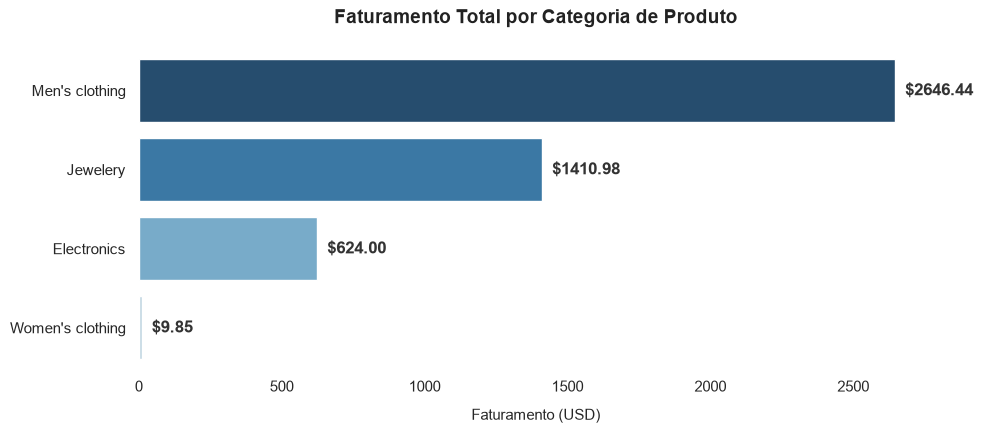

In [187]:
# --- GRÁFICO 1: Faturamento Total por Categoria ---

df_categoria = con.sql("""
    SELECT 
        UPPER(SUBSTR(categoria, 1, 1)) || SUBSTR(categoria, 2) AS categoria,
        ROUND(SUM(quantidade * preco), 2) AS faturamento_total
    FROM carts_clean i
    INNER JOIN products p ON i.id_produto = p.id_produto
    GROUP BY categoria
    ORDER BY faturamento_total DESC
""").df()

fig, ax1 = plt.subplots(figsize=(10, 4.5))

sns.barplot(
    x="faturamento_total", 
    y="categoria", 
    data=df_categoria, 
    palette=PALETA_PRINCIPAL,
    hue="categoria",
    legend=False,
    ax=ax1
)

for container in ax1.containers:
    ax1.bar_label(container, fmt='  $%1.2f', color='#333333', weight='bold')

sns.despine(left=True, bottom=True)
ax1.xaxis.grid(False)

plt.title("Faturamento Total por Categoria de Produto", pad=20, weight='bold', color='#222222')
plt.xlabel("Faturamento (USD)", labelpad=10)
plt.ylabel("")
plt.tight_layout()
plt.show()

### Faturamento por Categoria
A distribuição de receita apresenta uma forte concentração na categoria *Men's Clothing* ($2.646,44), que sozinha supera a soma de todas as demais categorias mapeadas. O segmento de *Women's Clothing* registrou o faturamento mais baixo ($9,85). 

**Investigação e possíveis planos de ação iniciais:**
* Alinhamento com o setor de compras para avaliar o nível de estoque de *Men's Clothing* e *Jewelry*, mitigando o risco de ruptura nos SKUs de maior giro.
* Investigar junto à equipe de engenharia/sistemas se o baixo faturamento de *Women's Clothing* decorre de uma real ausência de demanda ou de falhas de catalogação, indisponibilidade de estoque no banco de dados ou problemas de exibição no front-end.

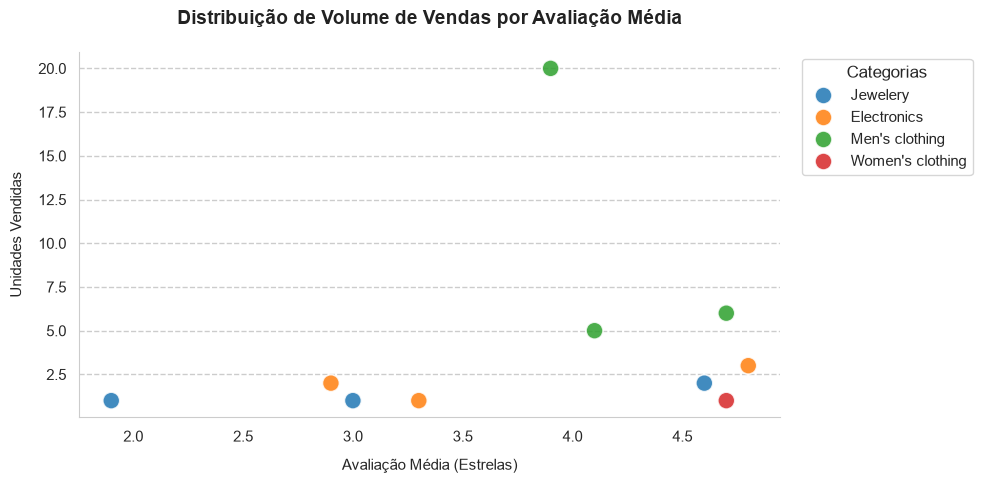

In [188]:
# --- GRÁFICO 2: Volume de Vendas vs. Avaliação Média ---

df_produtos = con.sql("""
    SELECT 
        SUM(i.quantidade) AS unidades_vendidas,
        p.avaliacao_media,
        UPPER(SUBSTR(p.categoria, 1, 1)) || SUBSTR(p.categoria, 2) AS categoria
    FROM carts_clean i
    INNER JOIN products p ON i.id_produto = p.id_produto
    GROUP BY p.id_produto, p.avaliacao_media, p.categoria
""").df()

fig, ax2 = plt.subplots(figsize=(10, 5))

sns.scatterplot(
    x="avaliacao_media", 
    y="unidades_vendidas", 
    hue="categoria",
    data=df_produtos,
    palette="tab10",
    s=150,
    alpha=0.85,
    edgecolor="w",
    linewidth=1.2,
    ax=ax2
)

sns.despine()
ax2.yaxis.grid(True)

plt.title("Distribuição de Volume de Vendas por Avaliação Média", pad=20, weight='bold', color='#222222')
plt.xlabel("Avaliação Média (Estrelas)", labelpad=10)
plt.ylabel("Unidades Vendidas", labelpad=10)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Categorias", frameon=True)
plt.tight_layout()
plt.show()

### Distribuição de Volume de Vendas vs. Avaliação Média
O gráfico de dispersão demonstra uma assimetria amostral severa. O SKU com maior volume de saídas (20 unidades) possui nota 3.9, representando o comportamento consolidado da maior parcela de transações. Inversamente, as avaliações mais altas (4.5 a 5.0) estão atreladas a produtos com volume de vendas crítico (1 a 2 unidades).

**Investigação e possíveis planos de ação iniciais:**
* Identifica-se que as avaliações máximas não são estatisticamente representativas devido ao tamanho amostral insuficiente ($n \le 2$). É necessário aguardar o incremento no volume de transações desses SKUs para estabilização da média e validação da real satisfação do cliente.
* Como o item de 20 unidades sustenta o giro do e-commerce, recomenda-se uma análise de sentimento qualitativa nos comentários de nota 3.9 para identificar oportunidades de melhoria no produto ou no processo de entrega, blindando a principal receita da operação.

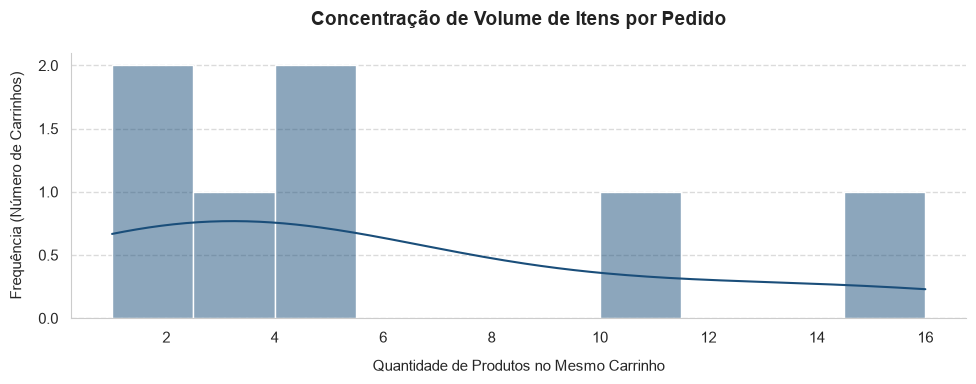

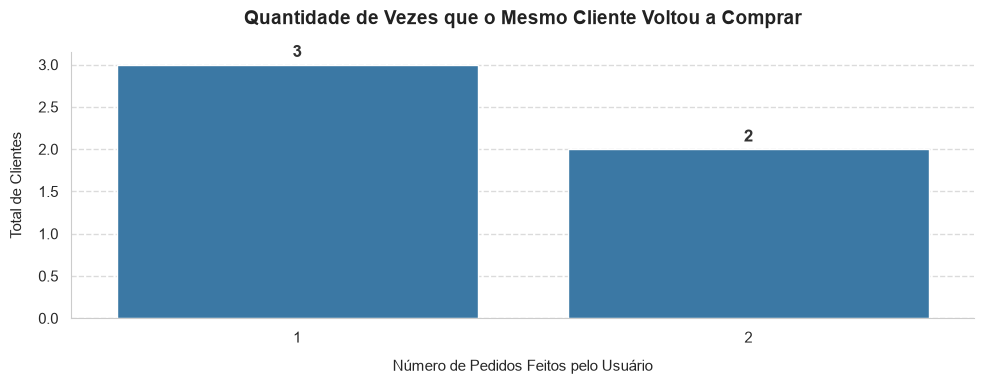

In [189]:
# --- GRÁFICO 3: Distribuição de Itens por Carrinho ---

df_itens_por_carrinho = con.sql("""
    SELECT 
        id_carrinho,
        SUM(quantidade) AS total_itens
    FROM carts_clean
    GROUP BY id_carrinho
""").df()

fig, ax3 = plt.subplots(figsize=(10, 4))

sns.histplot(
    data=df_itens_por_carrinho, 
    x="total_itens", 
    kde=True, 
    color="#1a4e7a", 
    bins=10,
    ax=ax3
)

sns.despine()
ax3.yaxis.grid(True, linestyle="--", alpha=0.7)
ax3.xaxis.grid(False)

plt.title("Concentração de Volume de Itens por Pedido", pad=20, weight='bold', color='#222222')
plt.xlabel("Quantidade de Produtos no Mesmo Carrinho", labelpad=10)
plt.ylabel("Frequência (Número de Carrinhos)", labelpad=10)
plt.tight_layout()
plt.show()

# --- GRÁFICO 4: Frequência de Compra por Usuário ---

df_frequencia_usuario = con.sql("""
    SELECT 
        id_usuario,
        COUNT(DISTINCT id_carrinho) AS total_compras
    FROM carts_clean
    GROUP BY id_usuario
""").df()

fig, ax4 = plt.subplots(figsize=(10, 4))

sns.countplot(
    data=df_frequencia_usuario, 
    x="total_compras", 
    color="#297bb6",
    ax=ax4
)

for container in ax4.containers:
    ax4.bar_label(container, color='#333333', weight='bold', label_type='edge', padding=3)

sns.despine()
ax4.yaxis.grid(True, linestyle="--", alpha=0.7)
ax4.xaxis.grid(False)

plt.title("Quantidade de Vezes que o Mesmo Cliente Voltou a Comprar", pad=20, weight='bold', color='#222222')
plt.xlabel("Número de Pedidos Feitos pelo Usuário", labelpad=10)
plt.ylabel("Total de Clientes", labelpad=10)
plt.tight_layout()
plt.show()

### Comportamento de Compra e Retenção de Clientes
A análise de recorrência indica que a maior parte da base de clientes registrada realizou apenas 1 pedido no intervalo observado, com uma minoria evoluindo para a segunda compra. Complementarmente, o histograma de volumetria indica que o tamanho dos carrinhos se concentra predominantemente abaixo de 6 itens, com registros isolados na cauda longa (10 a 16 itens).

**Investigação e possíveis planos de ação iniciais:**
* Propor à equipe de CRM o rastreamento do intervalo médio entre compras (*Time Between Purchases*). Caso o comportamento de compra única persista após o período estimado de recompra, faz-se necessária a validação de réguas de acionamento pós-venda.
* Avaliar a viabilidade técnica de regras de frete com base em faixas de valor ou volume para testar a sensibilidade do consumidor e incentivar o incremento de itens por transação nos clusters de baixa concentração.

In [190]:
# --- ANÁLISE DE AFINIDADE: PRODUTOS COMBINADOS (MARKET BASKET ANALYSIS) ---

query_afinidade = """
    WITH combinacoes_produtos AS (
        -- Encontra pares de produtos distintos que compartilham o mesmo id_carrinho
        SELECT 
            i1.id_produto AS id_prod_a,
            p1.titulo AS produto_a,
            i2.id_produto AS id_prod_b,
            p2.titulo AS produto_b,
            i1.id_carrinho
        FROM carts_clean i1
        INNER JOIN carts_clean i2 ON i1.id_carrinho = i2.id_carrinho
        -- Garante que não vamos cruzar o produto com ele mesmo e evita duplicidade invertida (A-B e B-A)
        AND i1.id_produto < i2.id_produto
        INNER JOIN products p1 ON i1.id_produto = p1.id_produto
        INNER JOIN products p2 ON i2.id_produto = p2.id_produto
    ),
    contagem_pares AS (
        -- Conta quantas vezes cada par de produtos foi comprado junto
        SELECT 
            produto_a,
            produto_b,
            COUNT(*) AS vezes_comprados_juntos
        FROM combinacoes_produtos
        GROUP BY produto_a, produto_b
    )
    -- Exibe o ranking das maiores afinidades do e-commerce
    SELECT 
        produto_a,
        produto_b,
        vezes_comprados_juntos
    FROM contagem_pares
    ORDER BY vezes_comprados_juntos DESC
    LIMIT 5
"""

print("--- TOP 5 PRODUTOS MAIS COMPRADOS JUNTOS ---")
con.sql(query_afinidade).show(max_width=120)

--- TOP 5 PRODUTOS MAIS COMPRADOS JUNTOS ---
┌──────────────────────────────────────────────┬──────────────────────────────────────────────┬────────────────────────┐
│                  produto_a                   │                  produto_b                   │ vezes_comprados_juntos │
│                   varchar                    │                   varchar                    │         int64          │
├──────────────────────────────────────────────┼──────────────────────────────────────────────┼────────────────────────┤
│ Fjallraven - Foldsack No. 1 Backpack, Fits 1 │ Mens Casual Premium Slim Fit T-Shirts        │                      2 │
│ 5 Laptops                                    │                                              │                        │
├──────────────────────────────────────────────┼──────────────────────────────────────────────┼────────────────────────┤
│ Fjallraven - Foldsack No. 1 Backpack, Fits 1 │ John Hardy Women's Legends Naga Gold & Silve │             

### Análise de Afinidade de Produtos
A execução do cruzamento matricial via SQL identificou que o par composto por *Fjallraven Backpack* e *Mens Casual T-Shirt* possui a maior frequência absoluta de coocorrência (2 compras conjuntas). As demais associações registram contagem unitária e envolvem itens de categorias distintas (como vestuário e joalheria), sem um padrão estatístico claro.

**Investigação e possíveis planos de ação iniciais:**
* O comportamento conjunto do par principal aponta uma complementaridade direta dentro do segmento de moda masculina. Sugere-se testar a exibição associada desses dois itens na jornada de compra para verificar o impacto na conversão.
* As ocorrências unitárias cruzadas (vestuário masculino e joias) devem ser tratadas como flutuações estatísticas normais de uma base inicial reduzida, não justificando alterações logísticas ou promocionais estruturais até que haja maior volume de dados.

In [191]:
# --- MODELAGEM DA DIMENSÃO CLIENTES ---

# Tratamento dos dados da tabela users_raw
con.execute("""
    CREATE OR REPLACE TABLE dim_clientes AS
    SELECT 
        CAST(id AS INTEGER) AS id_usuario,
        username AS nome_usuario,
        email,
        -- Corrige as aspas e extrai os campos do JSON plano usando caminhos JSON (JSONPath)
        CAST(json_extract(REPLACE(address, '''', '"'), '$.city') AS VARCHAR) AS cidade,
        CAST(json_extract(REPLACE(address, '''', '"'), '$.geolocation.lat') AS DECIMAL(9,6)) AS latitude,
        CAST(json_extract(REPLACE(address, '''', '"'), '$.geolocation.long') AS DECIMAL(9,6)) AS longitude
    FROM users_raw
""")

# Tabela users_raw tratada
print("--- TABELA DIMENSÃO CLIENTES E GEOLOCALIZAÇÃO ---")
con.sql("SELECT * FROM dim_clientes LIMIT 5").show()

--- TABELA DIMENSÃO CLIENTES E GEOLOCALIZAÇÃO ---
┌────────────┬──────────────┬────────────────────┬───────────────┬──────────────┬──────────────┐
│ id_usuario │ nome_usuario │       email        │    cidade     │   latitude   │  longitude   │
│   int32    │   varchar    │      varchar       │    varchar    │ decimal(9,6) │ decimal(9,6) │
├────────────┼──────────────┼────────────────────┼───────────────┼──────────────┼──────────────┤
│          1 │ johnd        │ john@gmail.com     │ "kilcoole"    │   -37.315900 │    81.149600 │
│          2 │ mor_2314     │ morrison@gmail.com │ "kilcoole"    │   -37.315900 │    81.149600 │
│          3 │ kevinryan    │ kevin@gmail.com    │ "Cullman"     │    40.346700 │   -30.131000 │
│          4 │ donero       │ don@gmail.com      │ "San Antonio" │    50.346700 │   -20.131000 │
│          5 │ derek        │ derek@gmail.com    │ "san Antonio" │    40.346700 │   -40.131000 │
└────────────┴──────────────┴────────────────────┴───────────────┴───────────

In [192]:
# Exportar tabelas normalizadas e limpas para novos arquivos CSV de produção
con.execute("COPY dim_clientes TO '../data/users_clean.csv' (HEADER, DELIMITER ',')")

print("Dados de produção exportados com sucesso para a pasta 'data/'!")

Dados de produção exportados com sucesso para a pasta 'data/'!


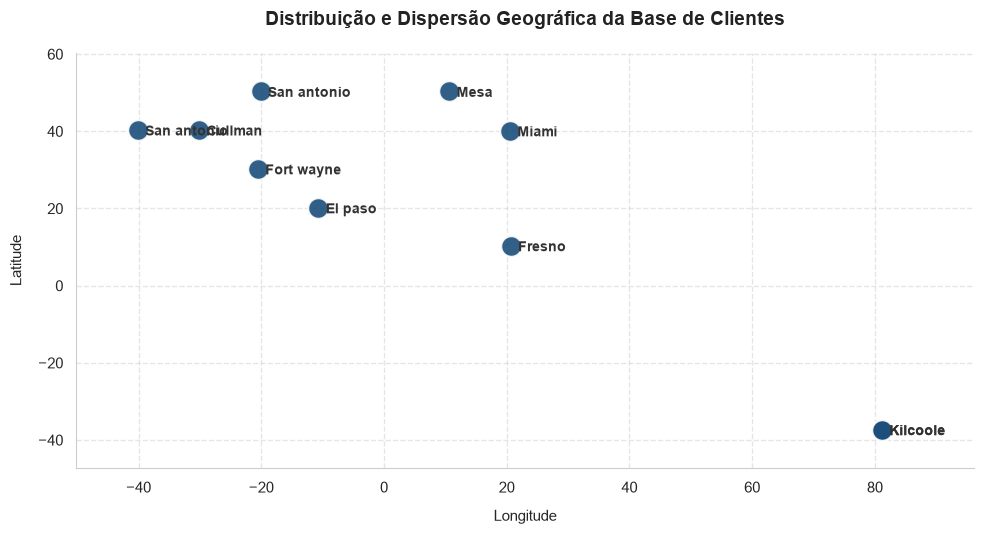

In [193]:
# --- GRÁFICO 5: MAPA DE DISPERSÃO GEOGRÁFICA DE CLIENTES ---

df_geo = con.sql("SELECT latitude, longitude, cidade FROM dim_clientes").df()

fig, ax5 = plt.subplots(figsize=(10, 5.5))

sns.scatterplot(
    x="longitude", 
    y="latitude", 
    data=df_geo, 
    s=220, 
    color="#1a4e7a", 
    alpha=0.9,
    edgecolor="w",
    linewidth=1.5,
    ax=ax5
)

for i in range(df_geo.shape[0]):
    cidade_limpa = df_geo.cidade[i].replace('"', '').capitalize()
    
    ax5.text(
        df_geo.longitude[i] + 1.2,
        df_geo.latitude[i] - 0.5,
        cidade_limpa, 
        horizontalalignment='left', 
        verticalalignment='center',
        size='small', 
        color='#333333', 
        weight='bold'
    )

sns.despine()
ax5.grid(True, linestyle="--", alpha=0.5)

plt.xlim(df_geo.longitude.min() - 10, df_geo.longitude.max() + 15)
plt.ylim(df_geo.latitude.min() - 10, df_geo.latitude.max() + 10)

plt.title("Distribuição e Dispersão Geográfica da Base de Clientes", pad=20, weight='bold', color='#222222')
plt.xlabel("Longitude", labelpad=10)
plt.ylabel("Latitude", labelpad=10)
plt.tight_layout()
plt.show()

### Distribuição Territorial da Base de Clientes
O mapeamento das coordenadas geográficas aponta uma distribuição com frequência unitária por localidade. Observa-se um grupo de consumidores localizados no Hemisfério Norte (cidades americanas como San Antonio, Miami e Mesa) e um registro no Hemisfério Sul (Kilcoole, com latitude $-37.31$ e longitude $81.14$).

**Investigação e possíveis planos de ação iniciais:**
* A pulverização geográfica internacional exige custos de frete fracionados elevados. É prioritário alinhar com o setor de logística a viabilidade financeira de atendimento dessas regiões ou se os dados geográficos da API representam apenas simulações cadastrais que divergem da localização real dos centros de distribuição.
* Verificar o processo de originação dos dados de endereço, uma vez que a presença de um único cliente em coordenadas isoladas pode indicar um cadastro incorreto ou uma oportunidade de restrição de entrega para otimização de margem operacional.